# Formula 1 (1950-2025): zona de puntos

Pregunta de negocio propia, exploracion y un modelo de clasificacion (CRISP-DM).

## 1. Comprension del negocio

Actor: estratega de una escuderia de media parrilla, donde cada punto define el premio de constructores. Pregunta: con lo conocido antes de largar (grilla, escuderia, circuito, forma reciente), se puede predecir si un piloto termina en zona de puntos (top 10)? La respuesta decide conservador vs. agresivo. No usamos columnas posteriores a la largada (anti-leakage).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 60)

## 2. Comprension de los datos

Cuatro tablas de f1db: carreras, resultados, pilotos y escuderias.

In [2]:
races = pd.read_csv("data/f1db-races.csv", low_memory=False)
results = pd.read_csv("data/f1db-races-race-results.csv", low_memory=False)
drivers = pd.read_csv("data/f1db-drivers.csv", low_memory=False)
constructors = pd.read_csv("data/f1db-constructors.csv", low_memory=False)
[("races", races.shape), ("results", results.shape),
 ("drivers", drivers.shape), ("constructors", constructors.shape)]

[('races', (1171, 43)),
 ('results', (27445, 34)),
 ('drivers', (917, 32)),
 ('constructors', (187, 22))]

In [3]:
res_cols = ["raceId", "year", "round", "positionNumber", "positionText", "driverId",
            "constructorId", "engineManufacturerId", "gridPositionNumber", "gridPositionText", "points"]
races_cols = ["id", "year", "round", "date", "grandPrixId", "circuitId", "circuitType"]

df = results[res_cols].merge(races[races_cols].rename(columns={"id": "raceId"}),
                             on=["raceId", "year", "round"], how="left")
df.head()

,raceId,year,round,positionNumber,positionText,driverId,constructorId,engineManufacturerId,gridPositionNumber,gridPositionText,points,date,grandPrixId,circuitId,circuitType
0,1,1950,1,1.0,1,nino-farina,alfa-romeo,alfa-romeo,1.0,1,9.0,1950-05-13,great-britain,silverstone,RACE
1,1,1950,1,2.0,2,luigi-fagioli,alfa-romeo,alfa-romeo,2.0,2,6.0,1950-05-13,great-britain,silverstone,RACE
2,1,1950,1,3.0,3,reg-parnell,alfa-romeo,alfa-romeo,4.0,4,4.0,1950-05-13,great-britain,silverstone,RACE
3,1,1950,1,4.0,4,yves-giraud-cabantous,talbot-lago,talbot-lago,6.0,6,3.0,1950-05-13,great-britain,silverstone,RACE
4,1,1950,1,5.0,5,louis-rosier,talbot-lago,talbot-lago,9.0,9,2.0,1950-05-13,great-britain,silverstone,RACE


In [4]:
df.shape, int(df.isnull().sum().sum()), df["year"].min(), df["year"].max()

((27445, 15), 33635, 1950, 2026)

### Valores faltantes y anomalias

Antes de recortar la ventana miramos los nulos columna por columna y revisamos si hay valores fuera de rango.

In [5]:
nulos = df.isnull().sum()
faltantes = (pd.DataFrame({"nulos": nulos, "pct": (nulos / len(df) * 100).round(1)})
             .query("nulos > 0").sort_values("nulos", ascending=False))
print("Faltantes por columna:")
print(faltantes)
print("\ngridPositionNumber -> min:", df["gridPositionNumber"].min(),
      "max:", df["gridPositionNumber"].max())
print("points -> min:", df["points"].min(), "max:", df["points"].max())
print("circuitType:", df["circuitType"].value_counts(dropna=False).to_dict())

Faltantes por columna:
                    nulos   pct
points              18963  69.1
positionNumber      10893  39.7
gridPositionNumber   2006   7.3
gridPositionText     1773   6.5

gridPositionNumber -> min: 1.0 max: 34.0
points -> min: 0.14 max: 50.0
circuitType: {'RACE': 20203, 'STREET': 5397, 'ROAD': 1845}


Los nulos altos de `points` (69%) y `positionNumber` (40%) no son datos rotos: son los autos que no terminaron (DNF, DNQ), justo lo que nuestro target marca como no puntua. La unica variable que despues usamos como feature y trae faltantes es `gridPositionNumber` (7%, autos sin tiempo de qualy o que largan del pit); la imputamos al fondo de parrilla en la preparacion. Los rangos no muestran anomalias: la grilla va de 1 a 34 (incluye pit-lane) y los puntos no superan el maximo posible por carrera.

### Ventana temporal

Nos quedamos con 2014-2025: reglas y puntaje estables.

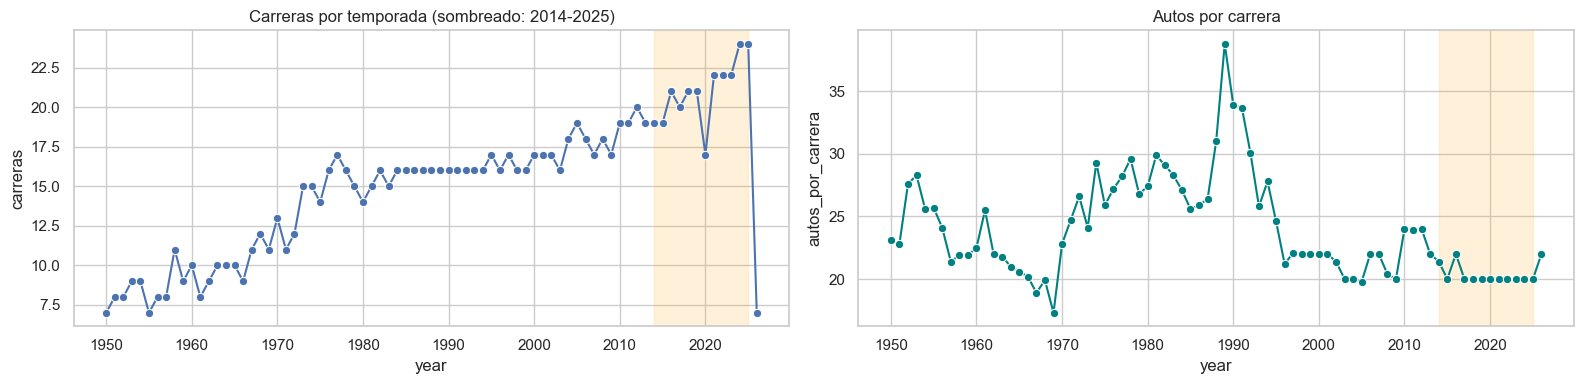

In [6]:
por_anio = df.groupby("year").agg(carreras=("raceId", "nunique"),
                                  autos_por_carrera=("driverId", "count")).reset_index()
por_anio["autos_por_carrera"] = (por_anio["autos_por_carrera"] / por_anio["carreras"]).round(1)
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
sns.lineplot(data=por_anio, x="year", y="carreras", ax=ax[0], marker="o")
ax[0].axvspan(2014, 2025, color="orange", alpha=0.15)
ax[0].set_title("Carreras por temporada (sombreado: 2014-2025)")
sns.lineplot(data=por_anio, x="year", y="autos_por_carrera", ax=ax[1], marker="o", color="teal")
ax[1].axvspan(2014, 2025, color="orange", alpha=0.15)
ax[1].set_title("Autos por carrera")
plt.tight_layout()
plt.show()

### Target

`puntua = 1` si termino top 10, si no 0.

In [7]:
dat = df[(df["year"] >= 2014) & (df["year"] <= 2025)].copy()
dat = dat.sort_values(["year", "round", "raceId"]).reset_index(drop=True)
dat["puntua"] = ((dat["positionNumber"].notna()) & (dat["positionNumber"] <= 10)).astype(int)
dat.shape, round(dat["puntua"].mean(), 3)

((5108, 16), 0.493)

In [8]:
resumen = pd.DataFrame({
    "metrica": ["filas (piloto-carrera)", "carreras", "temporadas", "pilotos", "escuderias", "circuitos", "tasa puntua (top10)"],
    "valor": [len(dat), dat["raceId"].nunique(), dat["year"].nunique(), dat["driverId"].nunique(),
              dat["constructorId"].nunique(), dat["circuitId"].nunique(), round(dat["puntua"].mean(), 3)]})
resumen

,metrica,valor
0,filas (piloto-carrera),5108.000
1,carreras,252.000
2,temporadas,12.000
3,pilotos,62.000
4,escuderias,22.000
5,circuitos,32.000
6,tasa puntua (top10),0.493


## 3. Exploracion

Cuanto pesan grilla, escuderia y tipo de circuito.

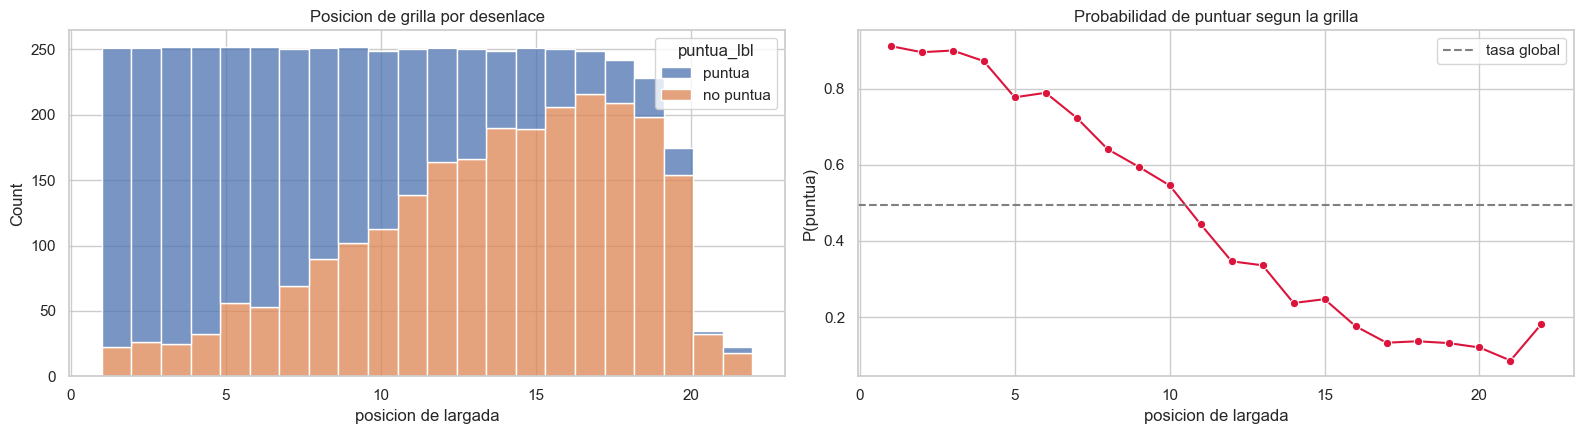

In [9]:
dat["puntua_lbl"] = dat["puntua"].map({1: "puntua", 0: "no puntua"})
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
sns.histplot(data=dat[dat["gridPositionNumber"].notna()], x="gridPositionNumber",
             hue="puntua_lbl", multiple="stack", bins=22, ax=ax[0])
ax[0].set_title("Posicion de grilla por desenlace")
ax[0].set_xlabel("posicion de largada")
tasa_grid = dat[dat["gridPositionNumber"].notna()].groupby("gridPositionNumber")["puntua"].mean().reset_index()
sns.lineplot(data=tasa_grid, x="gridPositionNumber", y="puntua", marker="o", ax=ax[1], color="crimson")
ax[1].axhline(dat["puntua"].mean(), ls="--", color="gray", label="tasa global")
ax[1].set_title("Probabilidad de puntuar segun la grilla")
ax[1].set_xlabel("posicion de largada"); ax[1].set_ylabel("P(puntua)"); ax[1].legend()
plt.tight_layout()
plt.show()

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_28868/591308847.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dat, y="constructorId", x="puntua", order=orden, errorbar=None, palette="viridis")


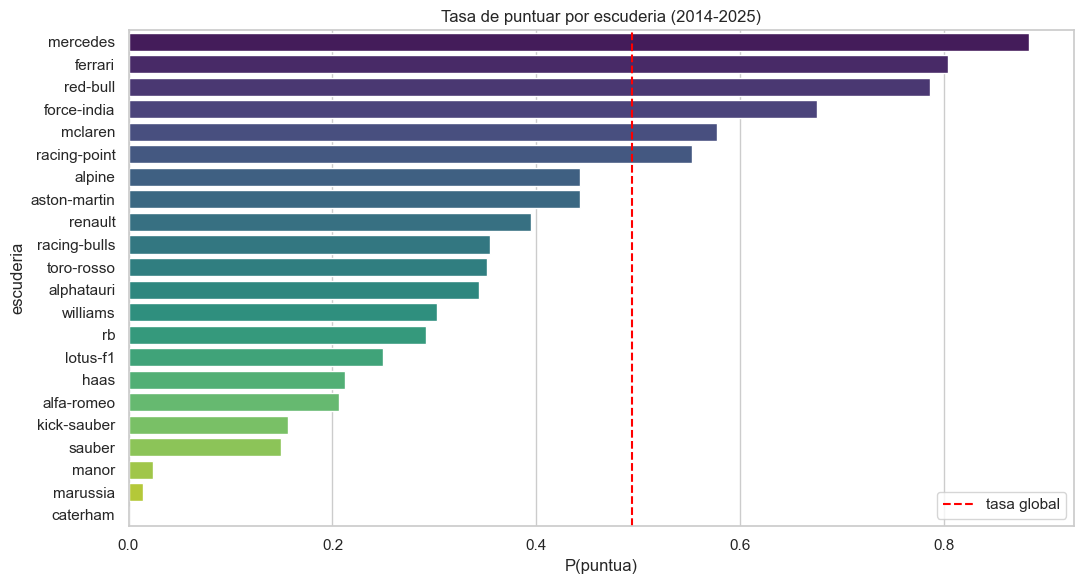

In [10]:
orden = dat.groupby("constructorId")["puntua"].mean().sort_values(ascending=False).index
plt.figure(figsize=(11, 6))
sns.barplot(data=dat, y="constructorId", x="puntua", order=orden, errorbar=None, palette="viridis")
plt.axvline(dat["puntua"].mean(), ls="--", color="red", label="tasa global")
plt.title("Tasa de puntuar por escuderia (2014-2025)")
plt.xlabel("P(puntua)"); plt.ylabel("escuderia"); plt.legend()
plt.tight_layout()
plt.show()

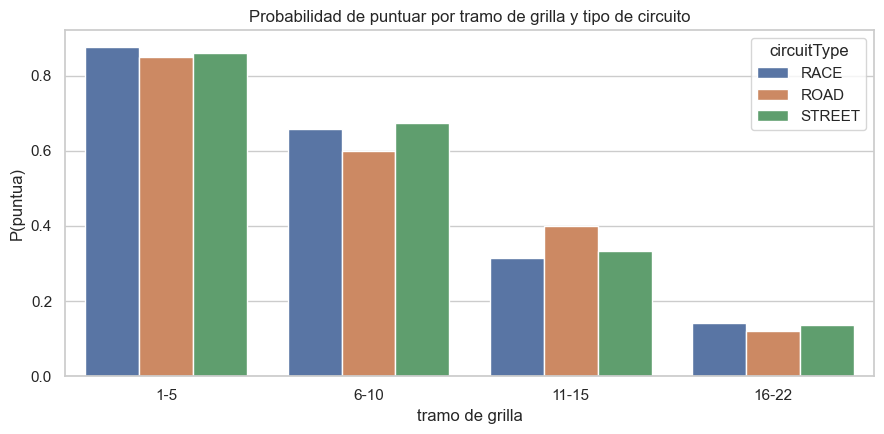

In [11]:
grid_circ = (dat[dat["gridPositionNumber"].notna()]
             .assign(grid_bin=pd.cut(dat["gridPositionNumber"], [0, 5, 10, 15, 22],
                                     labels=["1-5", "6-10", "11-15", "16-22"]))
             .groupby(["circuitType", "grid_bin"], observed=True)["puntua"].mean().reset_index())
plt.figure(figsize=(9, 4.5))
sns.barplot(data=grid_circ, x="grid_bin", y="puntua", hue="circuitType")
plt.title("Probabilidad de puntuar por tramo de grilla y tipo de circuito")
plt.xlabel("tramo de grilla"); plt.ylabel("P(puntua)")
plt.tight_layout()
plt.show()

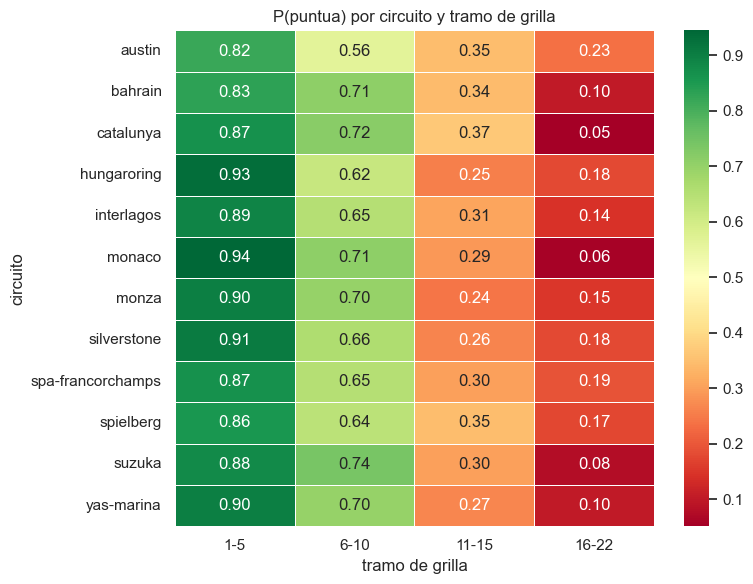

In [12]:
top_circ = dat["circuitId"].value_counts().head(12).index
sub = dat[(dat["circuitId"].isin(top_circ)) & (dat["gridPositionNumber"].notna())].copy()
piv = sub.pivot_table(index="circuitId",
                      columns=pd.cut(sub["gridPositionNumber"], [0, 5, 10, 15, 22],
                                     labels=["1-5", "6-10", "11-15", "16-22"]),
                      values="puntua", aggfunc="mean", observed=True)
plt.figure(figsize=(8, 6))
sns.heatmap(piv, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=.5)
plt.title("P(puntua) por circuito y tramo de grilla")
plt.xlabel("tramo de grilla"); plt.ylabel("circuito")
plt.tight_layout()
plt.show()

In [13]:
dat_g = dat[dat["gridPositionNumber"].notna()].copy()
fig = px.box(dat_g, x="puntua_lbl", y="gridPositionNumber", color="puntua_lbl",
             points=False, title="Grilla de partida segun el desenlace",
             labels={"puntua_lbl": "desenlace", "gridPositionNumber": "posicion de largada"})
fig.update_yaxes(autorange="reversed")
fig

Grilla y escuderia mandan; en callejeros la grilla pesa mas. Falta la forma reciente.

### Plan de trabajo (hacia la entrega final)

Lo que ya cerramos: pregunta de negocio, ventana 2014-2025, target `puntua` (top 10) y la exploracion de grilla, escuderia y tipo de circuito.

Lo que falta y como avanzamos:
- Construir la forma reciente del piloto y de la escuderia (media movil con `shift(1)`, solo carreras previas) para sumar el unico factor que la exploracion mostro pendiente.
- Armar un split temporal (entrenar con temporadas viejas, testear con las nuevas) en vez de un split aleatorio, para no mezclar el futuro con el pasado.
- Escalar y codificar (one-hot) ajustando solo en train, y entrenar tres clasificadores de la materia (LogReg, KNN, Random Forest) con validacion cruzada.
- Comparar contra un baseline simple (puntua el que larga top 10) para medir cuanto aporta el modelo por encima de la grilla del sabado.
- Entender los errores (matriz de confusion y tasa de error por tramo de grilla) y cerrar con la recomendacion para el estratega.

Datos externos: por ahora resolvemos la pregunta con las tablas del propio dataset. Si quedara tiempo, evaluamos sumar clima del circuito o resultado de qualy detallado, que es donde la exploracion sugiere que esta la zona gris del midfield; no es imprescindible para responder la pregunta.

## 4. Preparacion de los datos

Forma reciente con media movil y `shift(1)` (solo carreras anteriores); grilla faltante al fondo.

In [14]:
dat = dat.sort_values(["year", "round", "raceId"]).reset_index(drop=True)

dat["forma_piloto"] = (dat.groupby("driverId")["puntua"]
                       .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()))
dat["forma_constructor"] = (dat.groupby("constructorId")["puntua"]
                            .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean()))
dat["grid_media_constructor"] = (dat.groupby("constructorId")["gridPositionNumber"]
                                 .transform(lambda x: x.shift(1).rolling(10, min_periods=1).mean()))
dat[["driverId", "year", "round", "puntua", "forma_piloto", "forma_constructor"]].head(8)

,driverId,year,round,puntua,forma_piloto,forma_constructor
0,nico-rosberg,2014,1,1,NaN,NaN
1,kevin-magnussen,2014,1,1,NaN,NaN
2,jenson-button,2014,1,1,NaN,1.0
3,fernando-alonso,2014,1,1,NaN,NaN
4,valtteri-bottas,2014,1,1,NaN,NaN
5,nico-hulkenberg,2014,1,1,NaN,NaN
6,kimi-raikkonen,2014,1,1,NaN,1.0
7,jean-eric-vergne,2014,1,1,NaN,NaN


In [15]:
grid_fondo = 20.0
dat["gridPositionNumber"] = dat["gridPositionNumber"].fillna(grid_fondo)
dat["forma_piloto"] = dat["forma_piloto"].fillna(dat["puntua"].mean())
dat["forma_constructor"] = dat["forma_constructor"].fillna(dat["puntua"].mean())
dat["grid_media_constructor"] = dat["grid_media_constructor"].fillna(grid_fondo)
int(dat[["gridPositionNumber", "forma_piloto", "forma_constructor", "grid_media_constructor"]].isnull().sum().sum())

0

### Split temporal

Entrenamos con temporadas viejas (2014-2022) y testeamos con las nuevas (2023-2025).

In [16]:
num_feats = ["gridPositionNumber", "forma_piloto", "forma_constructor", "grid_media_constructor"]
cat_feats = ["constructorId", "circuitType"]

train = dat[dat["year"] <= 2022].copy()
test = dat[dat["year"] >= 2023].copy()
X_train, X_test = train[num_feats + cat_feats], test[num_feats + cat_feats]
y_train, y_test = train["puntua"], test["puntua"]
X_train.shape, X_test.shape, round(y_train.mean(), 3), round(y_test.mean(), 3)

((3709, 6), (1399, 6), 0.491, 0.5)

### Escalado y codificacion

Escalado y one-hot ajustados solo con train.

In [17]:
scaler = StandardScaler()
Xtr_num = scaler.fit_transform(X_train[num_feats])
Xte_num = scaler.transform(X_test[num_feats])

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
Xtr_cat = encoder.fit_transform(X_train[cat_feats])
Xte_cat = encoder.transform(X_test[cat_feats])

feat_names = num_feats + list(encoder.get_feature_names_out(cat_feats))
X_train_p = np.hstack([Xtr_num, Xtr_cat])
X_test_p = np.hstack([Xte_num, Xte_cat])
X_train_p.shape, X_test_p.shape

((3709, 26), (1399, 26))

## 5. Modelado

Tres clasificadores, con `cross_val_score` (cv=5) y test temporal.

In [18]:
models = {
    "LogReg": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_SEED),
    "KNN": KNeighborsClassifier(n_neighbors=11),
    "RandomForest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                           random_state=RANDOM_SEED, n_jobs=-1),
}
cv_scores = {}
for n, m in models.items():
    cv_scores[n] = cross_val_score(m, X_train_p, y_train, cv=5, scoring="f1").mean()
pd.Series(cv_scores, name="cv_f1").sort_values(ascending=False)

LogReg          0.770889
KNN             0.755843
RandomForest    0.742473
Name: cv_f1, dtype: float64

In [19]:
rows = []
fitted = {}
for n, m in models.items():
    m.fit(X_train_p, y_train)
    pred = m.predict(X_test_p)
    fitted[n] = m
    rows.append({"modelo": n,
                 "accuracy": round(accuracy_score(y_test, pred), 4),
                 "f1_puntua": round(f1_score(y_test, pred), 4),
                 "cv_f1": round(cv_scores[n], 4)})
tabla = pd.DataFrame(rows).sort_values("f1_puntua", ascending=False).reset_index(drop=True)
tabla

,modelo,accuracy,f1_puntua,cv_f1
0,LogReg,0.7920,0.7914,0.7709
1,RandomForest,0.7706,0.7751,0.7425
2,KNN,0.7655,0.7716,0.7558


### Baseline

Regla sin modelo: puntua el que larga top 10.

In [20]:
base_pred = (X_test["gridPositionNumber"] <= 10).astype(int)
best = tabla.iloc[0]["modelo"]
comp = pd.DataFrame([
    {"modelo": "baseline grilla<=10", "accuracy": round(accuracy_score(y_test, base_pred), 4),
     "f1_puntua": round(f1_score(y_test, base_pred), 4)},
    {"modelo": best, "accuracy": tabla.iloc[0]["accuracy"], "f1_puntua": tabla.iloc[0]["f1_puntua"]}])
comp

,modelo,accuracy,f1_puntua
0,baseline grilla<=10,0.7856,0.7857
1,LogReg,0.7920,0.7914


### Importancia de variables (Random Forest)

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_28868/1403736700.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=imp.values, y=imp.index, palette="viridis")


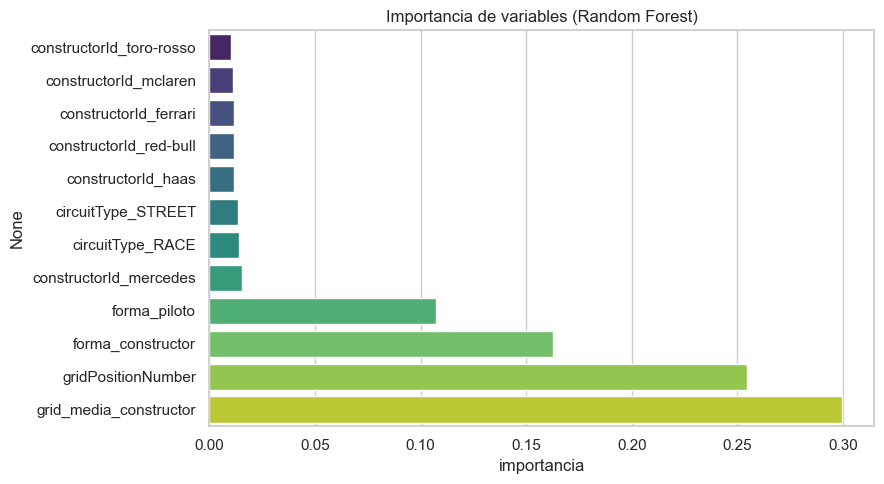

In [21]:
rf = fitted["RandomForest"]
imp = pd.Series(rf.feature_importances_, index=feat_names).sort_values().tail(12)
plt.figure(figsize=(9, 5))
sns.barplot(x=imp.values, y=imp.index, palette="viridis")
plt.title("Importancia de variables (Random Forest)")
plt.xlabel("importancia")
plt.tight_layout()
plt.show()

## 6. Evaluacion y errores

Reporte, matriz de confusion y donde falla.

In [22]:
bm = fitted[best]
pred = bm.predict(X_test_p)
print("Mejor modelo:", best)
print(classification_report(y_test, pred, target_names=["no puntua", "puntua"]))

Mejor modelo: LogReg
              precision    recall  f1-score   support

   no puntua       0.79      0.80      0.79       699
      puntua       0.79      0.79      0.79       700

    accuracy                           0.79      1399
   macro avg       0.79      0.79      0.79      1399
weighted avg       0.79      0.79      0.79      1399



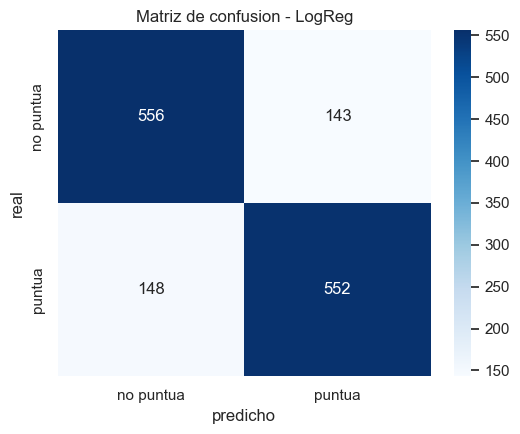

In [23]:
cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no puntua", "puntua"], yticklabels=["no puntua", "puntua"])
plt.title(f"Matriz de confusion - {best}")
plt.ylabel("real"); plt.xlabel("predicho")
plt.tight_layout()
plt.show()

/var/folders/pp/2w01y9pd6px1lfx6rs9vs5p00000gp/T/ipykernel_28868/1403963780.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=tasa_err.index.astype(str), y=tasa_err.values, palette="rocket")


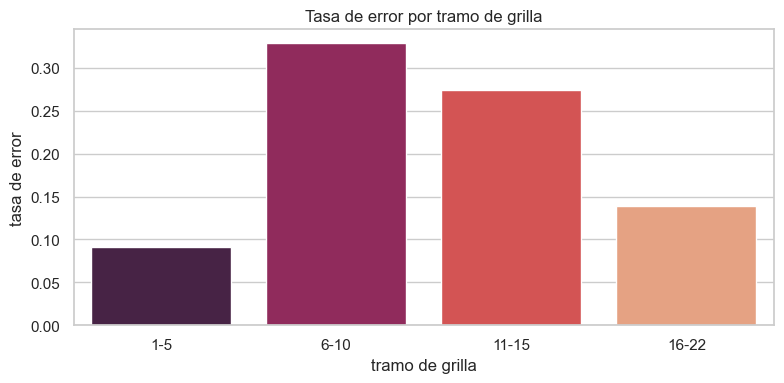

In [24]:
err = test.copy()
err["pred"] = pred
tasa_err = (err.assign(error=(err["puntua"] != err["pred"]).astype(int))
            .groupby(pd.cut(err["gridPositionNumber"], [0, 5, 10, 15, 22],
                            labels=["1-5", "6-10", "11-15", "16-22"]), observed=True)["error"].mean())
plt.figure(figsize=(8, 4))
sns.barplot(x=tasa_err.index.astype(str), y=tasa_err.values, palette="rocket")
plt.title("Tasa de error por tramo de grilla")
plt.xlabel("tramo de grilla"); plt.ylabel("tasa de error")
plt.tight_layout()
plt.show()

El error se concentra en la zona media de la parrilla (6-15), donde se juega el midfield.

## 7. Conclusiones y recomendacion

Se anticipa con buena precision quien puntua con info previa a la largada, pero el modelo apenas le gana al baseline: la grilla del sabado ya ordena casi todo.

Recomendacion: usar la probabilidad como semaforo (alta, conservador; baja, arriesgar), en la zona gris pesar clima y neumaticos, e invertir en mejorar la clasificacion del sabado.